<a href="https://colab.research.google.com/github/Tanbir-Hasan-247/Colab-file/blob/main/Class_2_Spring_2026_(AI_LAB).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###1. Learning Objectives
By the end of this lab, students should be able to:

✅ Understand Linear Regression and its importance in Machine Learning.

✅ Derive Mathematical Formulation of Linear Regression.

✅ Implement Simple and Multiple Linear Regression using Python.

✅ Evaluate Regression Models using performance metrics.

✅ Perform Feature Engineering and Selection for better model performance.

✅ Visualize Regression Line and Predictions.

### 2. Theoretical Questions & Answers

####Q1: What is Linear Regression?


* Linear Regression is a supervised machine learning algorithm used for predicting continuous values (e.g., house prices, stock prices, etc.).
* It assumes a linear relationship between the input features (X) and the target variable (Y).

####Q2: Mathematical Formulation of Linear Regression

For one feature (Simple Linear Regression):
$$Y=mX+c$$
* Y → Target variable (Predicted Output)
* X → Feature variable (Input)
* m → Slope (Weight of X)
* c → Intercept (Bias)

For multiple features (Multiple Linear Regression):
$$
Y=β_0
 +β_1X_1 +β_2X_2 +⋯+β_nX_n$$
 * β (Beta coefficients) are learned using Gradient Descent or Least Squares method.

 * The model minimizes Mean Squared Error (MSE)


#=====================================================================================================

###3. Importing Libraries and Dataset

📌 Dataset: Boston Housing Prices Dataset (Predict house prices based on various features).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing

# Load dataset
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["Price"] = data.target  # Target variable

# Display first 5 rows
print(df.head())


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


In [ ]:
print(df)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  Price  
0        -122

In [ ]:
# Display all rows
pd.set_option('display.max_rows', None)

# Display all columns
pd.set_option('display.max_columns', None)

# Print the entire dataset
print(df)

# Reset settings after viewing (optional)
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

        MedInc  HouseAge    AveRooms  AveBedrms  Population     AveOccup  \
0       8.3252      41.0    6.984127   1.023810       322.0     2.555556   
1       8.3014      21.0    6.238137   0.971880      2401.0     2.109842   
2       7.2574      52.0    8.288136   1.073446       496.0     2.802260   
3       5.6431      52.0    5.817352   1.073059       558.0     2.547945   
4       3.8462      52.0    6.281853   1.081081       565.0     2.181467   
5       4.0368      52.0    4.761658   1.103627       413.0     2.139896   
6       3.6591      52.0    4.931907   0.951362      1094.0     2.128405   
7       3.1200      52.0    4.797527   1.061824      1157.0     1.788253   
8       2.0804      42.0    4.294118   1.117647      1206.0     2.026891   
9       3.6912      52.0    4.970588   0.990196      1551.0     2.172269   
10      3.2031      52.0    5.477612   1.079602       910.0     2.263682   
11      3.2705      52.0    4.772480   1.024523      1504.0     2.049046   
12      3.07

###4. Exploratory Data Analysis (EDA)

📌 Understanding Data Distribution

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude         Price  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

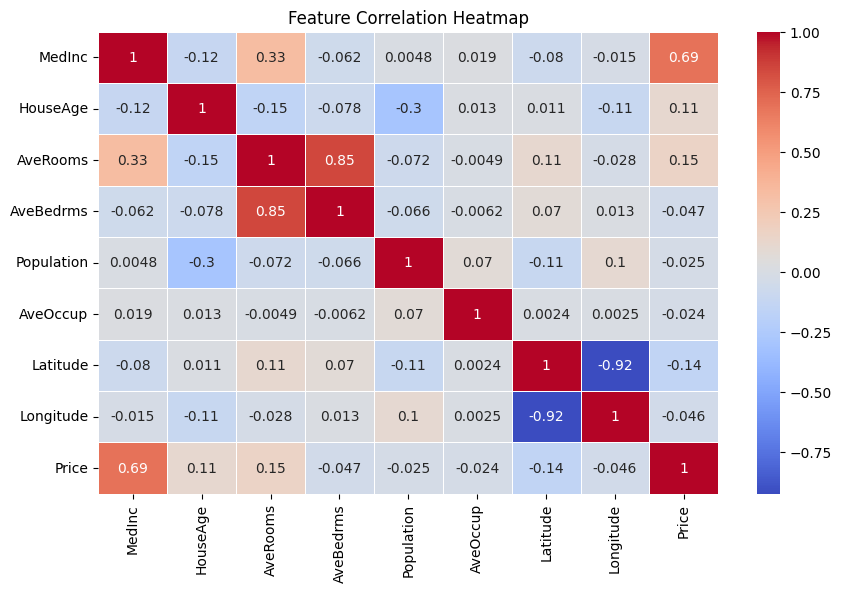

In [ ]:
# Display summary statistics
print(df.describe())

# Check for missing values
print("\nMissing Values:\n", df.isnull().sum())

# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

✔ Insight: High correlation between MedInc (Median Income) and Price.


###5. Splitting Data into Training and Testing Sets

📌 80% Training – 20% Testing

In [ ]:
# Define features (X) and target variable (Y)
X = df.drop(columns=["Price"])
Y = df["Price"]

# Split data into training and testing sets (80-20 split)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Normalize data (Standardization)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (16512, 8)
Testing Data Shape: (4128, 8)


In [ ]:
print(X_train)

[[-0.326196    0.34849025 -0.17491646 ...  0.05137609 -1.3728112
   1.27258656]
 [-0.03584338  1.61811813 -0.40283542 ... -0.11736222 -0.87669601
   0.70916212]
 [ 0.14470145 -1.95271028  0.08821601 ... -0.03227969 -0.46014647
  -0.44760309]
 ...
 [-0.49697313  0.58654547 -0.60675918 ...  0.02030568 -0.75500738
   0.59946887]
 [ 0.96545045 -1.07984112  0.40217517 ...  0.00707608  0.90651045
  -1.18553953]
 [-0.68544764  1.85617335 -0.85144571 ... -0.08535429  0.99543676
  -1.41489815]]


✔ Feature Scaling ensures better convergence for linear regression.

###6. Implementing Linear Regression

(A) Simple Linear Regression (One Feature)

📌 Train on MedInc (Median Income) to predict Price


Multiple Linear Regression Performance:
Mean Absolute Error (MAE): 0.629908653009376
Mean Squared Error (MSE): 0.7091157771765549
R-squared (R²) Score: 0.45885918903846656


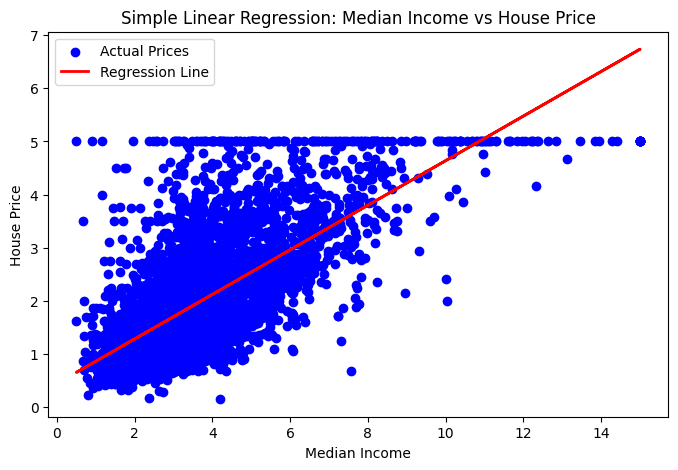

In [ ]:
# Select one feature for simple linear regression
X_simple = df[["MedInc"]]
Y_simple = df["Price"]

# Train-Test Split
X_train_simple, X_test_simple, Y_train_simple, Y_test_simple = train_test_split(X_simple, Y_simple, test_size=0.2, random_state=42)

# Train Simple Linear Regression Model
simple_model = LinearRegression()
simple_model.fit(X_train_simple, Y_train_simple)

# Predict and Plot Regression Line
Y_pred_simple = simple_model.predict(X_test_simple)

print("\nMultiple Linear Regression Performance:")
print("Mean Absolute Error (MAE):", mean_absolute_error(Y_test, Y_pred_simple))
print("Mean Squared Error (MSE):", mean_squared_error(Y_test, Y_pred_simple))
print("R-squared (R²) Score:", r2_score(Y_test,Y_pred_simple ))

plt.figure(figsize=(8, 5))
plt.scatter(X_test_simple, Y_test_simple, color="blue", label="Actual Prices")
plt.plot(X_test_simple, Y_pred_simple, color="red", linewidth=2, label="Regression Line")
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Simple Linear Regression: Median Income vs House Price")
plt.legend()
plt.show()

✔ The red line represents the linear relationship between Median Income and Price.



(B) Multiple Linear Regression (All Features)

In [ ]:
# Train Multiple Linear Regression Model
multi_model = LinearRegression()
multi_model.fit(X_train, Y_train)

# Predictions
Y_pred_multi = multi_model.predict(X_test)

# Model Performance Evaluation
print("\nMultiple Linear Regression Performance:")
print("Mean Absolute Error (MAE):", mean_absolute_error(Y_test, Y_pred_multi))
print("Mean Squared Error (MSE):", mean_squared_error(Y_test, Y_pred_multi))
print("R-squared (R²) Score:", r2_score(Y_test, Y_pred_multi))


Multiple Linear Regression Performance:
Mean Absolute Error (MAE): 0.5332001304956565
Mean Squared Error (MSE): 0.5558915986952442
R-squared (R²) Score: 0.575787706032451


✔ R² Score tells us how well the model fits the data. A higher value (closer to 1) indicates a good fit.

###7. Advanced Topics: Feature Selection
(A) Feature Importance Using Coefficients

<ipython-input-24-7d7b7857d861>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Coefficient", y="Feature", data=coefficients, palette="viridis")


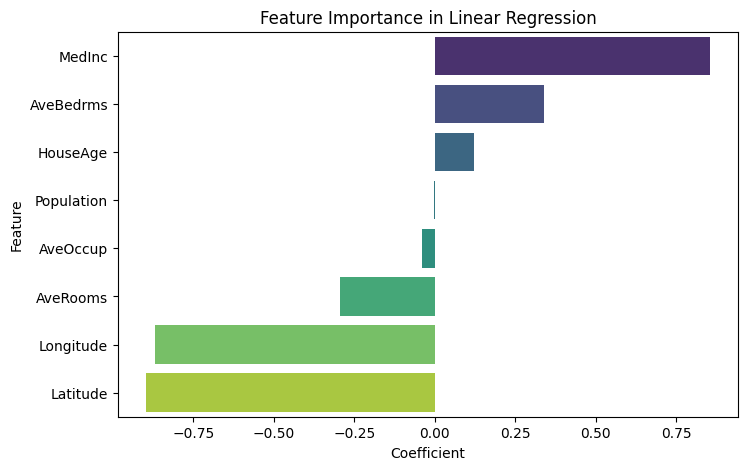

In [ ]:
# Get feature importance
coefficients = pd.DataFrame({"Feature": X.columns, "Coefficient": multi_model.coef_})
coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

# Plot Feature Importance
plt.figure(figsize=(8, 5))
sns.barplot(x="Coefficient", y="Feature", data=coefficients, palette="viridis")
plt.title("Feature Importance in Linear Regression")
plt.show()

✔ Higher coefficient values indicate stronger impact on house prices.

### 🔹 Homework Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_diabetes

# Step 1: Load and Explore the Dataset
diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df["target"] = diabetes.target  #Diabetes Progression Score (disease severity)


# Display first 5 rows
print("First 5 Rows of Dataset:\n", df.head())

First 5 Rows of Dataset:
         age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


### **🔹 Homework Tasks**
Complete the following tasks and submit your code along with answers to the theoretical questions.

### **✅ Task 1: Data Exploration**
1. **Check for missing values** in the dataset.
2. **Display summary statistics** (mean, min, max, standard deviation).
3. **Plot a correlation heatmap** to identify relationships between features and target.

📌 **Hint:** Use `df.isnull().sum()`, `df.describe()`, and `sns.heatmap()`.

---

### **✅ Task 2: Data Preprocessing**
1. **Split the dataset** into **80% training and 20% testing** sets.
2. **Standardize the features** using `StandardScaler()`.

📌 **Hint:** Use `train_test_split()` and `StandardScaler()`.

---

### **✅ Task 3: Implement Simple Linear Regression**
1. Train **Simple Linear Regression** using **one feature** (e.g., `bmi`) to predict `target`.
2. Make **predictions** on the test set.
3. **Plot the regression line** against actual values.

📌 **Hint:** Use `sns.regplot()` for visualization.

---

### **✅ Task 4: Implement Multiple Linear Regression**
1. Train **Multiple Linear Regression** using **all features** to predict `target`.
2. Make **predictions** on the test set.
3. Evaluate the model using:
   - **Mean Absolute Error (MAE)**
   - **Mean Squared Error (MSE)**
   - **R-squared (R²) Score**

📌 **Hint:** Use `LinearRegression()` and `mean_absolute_error()`.

---

### **✅ Task 5: Feature Importance Analysis**
1. Extract **regression coefficients** to identify **most important features**.
2. **Plot feature importance** using a bar chart.

📌 **Hint:** Use `model.coef_` and `sns.barplot()`.